In [1]:
# !unzip "/content/brugada-huca.zip"

In [2]:
import os
import numpy as np
import pandas as pd
!pip install wfdb
import wfdb
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              f1_score, recall_score, precision_score)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {device}')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


PyTorch version : 2.4.1+cu121
CUDA available  : False
Device          : cpu


c:\Users\A S U S\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:128: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10\cuda\CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
BASE_DIR  = r'D:/Academic Competition/Data Science/IIDSC'
META_PATH = os.path.join(BASE_DIR, 'metadata.csv')
FILES_DIR = os.path.join(BASE_DIR, 'files')

print(f'BASE_DIR  : {BASE_DIR}')
print(f'META_PATH : {META_PATH}')
print(f'FILES_DIR : {FILES_DIR}')

BASE_DIR  : D:/Academic Competition/Data Science/IIDSC
META_PATH : D:/Academic Competition/Data Science/IIDSC\metadata.csv
FILES_DIR : D:/Academic Competition/Data Science/IIDSC\files


In [4]:
def load_ecg(patient_id):
    path = os.path.join(FILES_DIR, str(patient_id), str(patient_id))
    record = wfdb.rdrecord(path)
    return record.p_signal, record.sig_name, record.fs

metadata = pd.read_csv(META_PATH)
metadata['label'] = (metadata['brugada'] > 0).astype(int)

all_signals, all_labels = [], []

for _, row in metadata.iterrows():
    sig, lead_names, fs = load_ecg(row['patient_id'])
    all_signals.append(sig)
    all_labels.append(row['label'])

all_signals = np.array(all_signals)   # (363, 1200, 12)
all_labels  = np.array(all_labels)    # (363,)

print(f'Shape signals : {all_signals.shape}')
print(f'Shape labels  : {all_labels.shape}')
print(f'Normal        : {(all_labels==0).sum()}')
print(f'Brugada       : {(all_labels==1).sum()}')

Shape signals : (363, 1200, 12)
Shape labels  : (363,)
Normal        : 287
Brugada       : 76


In [5]:
def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=100, order=4):
    nyq  = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal, axis=0)

def minmax_normalize(signal):
    sig_min = signal.min(axis=0)
    sig_max = signal.max(axis=0)
    denom   = sig_max - sig_min
    denom[denom == 0] = 1
    return (signal - sig_min) / denom

all_signals_filtered = np.array([bandpass_filter(sig) for sig in all_signals])
all_signals_norm     = np.array([minmax_normalize(sig) for sig in all_signals_filtered])

print(f'Shape : {all_signals_norm.shape}')
print(f'Min   : {all_signals_norm.min():.4f}')
print(f'Max   : {all_signals_norm.max():.4f}')

Shape : (363, 1200, 12)
Min   : 0.0000
Max   : 1.0000


In [6]:
class ECGDataset(Dataset):
    """
    Custom PyTorch Dataset untuk sinyal ECG
    Input shape  : (1200, 12)
    Output shape : (12, 1200)  — CNN 1D butuh (channels, length)
    """
    def __init__(self, signals, labels):
        # Transpose: (N, 1200, 12) → (N, 12, 1200)
        self.X = torch.tensor(
            signals.transpose(0, 2, 1), dtype=torch.float32
        )
        self.y = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Test dataset
test_ds = ECGDataset(all_signals_norm, all_labels)
print(f'Dataset size   : {len(test_ds)}')
print(f'Signal shape   : {test_ds[0][0].shape}')
print(f'Label          : {test_ds[0][1]}')

Dataset size   : 363
Signal shape   : torch.Size([12, 1200])
Label          : 1.0


In [7]:
class ECG_CNN1D(nn.Module):
    def __init__(self, n_leads=12, dropout=0.5):
        super(ECG_CNN1D, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv1d(n_leads, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),       # 1200 → 600
            nn.Dropout(0.2)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),       # 600 → 300
            nn.Dropout(0.2)
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),       # 300 → 150
            nn.Dropout(0.2)
        )

        # Block 4
        self.block4 = nn.Sequential(
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)            # → (256, 1)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x.squeeze(1)

# Test arsitektur
model_test = ECG_CNN1D().to(device)
dummy = torch.randn(4, 12, 1200).to(device)
output = model_test(dummy)
print(f'Input shape  : {dummy.shape}')
print(f'Output shape : {output.shape}')
print(f'Output range : {output.min():.4f} - {output.max():.4f}')
print(f'\nModel summary:')
total_params = sum(p.numel() for p in model_test.parameters())
print(f'Total parameters : {total_params:,}')

Input shape  : torch.Size([4, 12, 1200])
Output shape : torch.Size([4])
Output range : 0.5093 - 0.5594

Model summary:
Total parameters : 376,385


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    all_signals_norm, all_labels,
    test_size=0.2, random_state=42, stratify=all_labels
)

train_ds = ECGDataset(X_train, y_train)
test_ds  = ECGDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False)

print(f'Train size : {len(train_ds)}')
print(f'Test size  : {len(test_ds)}')
print(f'y_train    — Normal: {(y_train==0).sum()} | Brugada: {(y_train==1).sum()}')
print(f'y_test     — Normal: {(y_test==0).sum()}  | Brugada: {(y_test==1).sum()}')

Train size : 290
Test size  : 73
y_train    — Normal: 229 | Brugada: 61
y_test     — Normal: 58  | Brugada: 15


In [9]:
# Class weight untuk loss function
class_weights = compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
pos_weight = torch.tensor(
    class_weights[1] / class_weights[0], dtype=torch.float32
).to(device)

print(f'Pos weight : {pos_weight:.4f}')

model     = ECG_CNN1D(dropout=0.5).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

Pos weight : 3.7541


In [10]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss   = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss   = criterion(output, y_batch)
            total_loss += loss.item()
            probs = torch.sigmoid(output)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    return total_loss / len(loader), np.array(all_probs), np.array(all_labels)

# Training
N_EPOCHS   = 100
best_loss  = float('inf')
best_model = None
train_losses, val_losses = [], []

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_probs, val_true = eval_epoch(model, test_loader, criterion, device)

    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Simpan model terbaik
    if val_loss < best_loss:
        best_loss  = val_loss
        best_model = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        val_preds = (val_probs >= 0.5).astype(int)
        f1  = f1_score(val_true, val_preds, zero_division=0)
        rec = recall_score(val_true, val_preds, zero_division=0)
        print(f'Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | F1: {f1:.4f} | Recall: {rec:.4f}')

print(f'\nTraining selesai. Best val loss: {best_loss:.4f}')

Epoch  10 | Train Loss: 0.9897 | Val Loss: 1.0819 | F1: 0.3409 | Recall: 1.0000
Epoch  20 | Train Loss: 1.0261 | Val Loss: 0.9421 | F1: 0.3409 | Recall: 1.0000
Epoch  30 | Train Loss: 0.9236 | Val Loss: 0.8905 | F1: 0.3409 | Recall: 1.0000
Epoch  40 | Train Loss: 0.8864 | Val Loss: 0.8651 | F1: 0.3409 | Recall: 1.0000
Epoch  50 | Train Loss: 0.8663 | Val Loss: 0.8446 | F1: 0.3409 | Recall: 1.0000
Epoch  60 | Train Loss: 0.8711 | Val Loss: 0.8554 | F1: 0.3409 | Recall: 1.0000
Epoch  70 | Train Loss: 0.8616 | Val Loss: 0.8477 | F1: 0.3409 | Recall: 1.0000
Epoch  80 | Train Loss: 0.8468 | Val Loss: 0.8511 | F1: 0.3409 | Recall: 1.0000
Epoch  90 | Train Loss: 0.8623 | Val Loss: 0.8502 | F1: 0.3409 | Recall: 1.0000
Epoch 100 | Train Loss: 0.9672 | Val Loss: 0.8554 | F1: 0.3409 | Recall: 1.0000

Training selesai. Best val loss: 0.8433


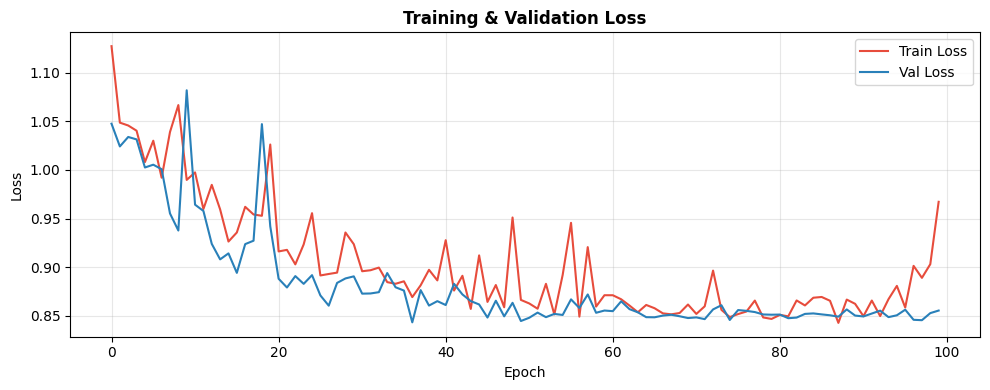

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, color='#e74c3c', linewidth=1.5, label='Train Loss')
plt.plot(val_losses,   color='#2980b9', linewidth=1.5, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Load model terbaik
model.load_state_dict(best_model)

_, test_probs, test_true = eval_epoch(model, test_loader, criterion, device)

# Threshold tuning
results_thr = []
for thr in np.arange(0.1, 0.9, 0.05):
    preds = (test_probs >= thr).astype(int)
    results_thr.append({
        'threshold' : round(thr, 2),
        'recall'    : recall_score(test_true, preds, zero_division=0),
        'precision' : precision_score(test_true, preds, zero_division=0),
        'f1'        : f1_score(test_true, preds, zero_division=0)
    })

df_thr    = pd.DataFrame(results_thr)
best_thr  = df_thr.loc[df_thr['f1'].idxmax(), 'threshold']
test_preds = (test_probs >= best_thr).astype(int)

print(df_thr.to_string(index=False))
print(f'\nThreshold terbaik : {best_thr}')
print(f'\n=== CNN 1D (threshold={best_thr}) ===')
print(classification_report(test_true, test_preds, target_names=['Normal', 'Brugada']))
print(f'AUC-ROC : {roc_auc_score(test_true, test_probs):.4f}')

 threshold   recall  precision       f1
      0.10 1.000000   0.205479 0.340909
      0.15 1.000000   0.205479 0.340909
      0.20 1.000000   0.205479 0.340909
      0.25 1.000000   0.205479 0.340909
      0.30 1.000000   0.205479 0.340909
      0.35 1.000000   0.205479 0.340909
      0.40 1.000000   0.205479 0.340909
      0.45 1.000000   0.205479 0.340909
      0.50 0.933333   0.233333 0.373333
      0.55 0.866667   0.866667 0.866667
      0.60 0.800000   0.923077 0.857143
      0.65 0.800000   1.000000 0.888889
      0.70 0.666667   1.000000 0.800000
      0.75 0.000000   0.000000 0.000000
      0.80 0.000000   0.000000 0.000000
      0.85 0.000000   0.000000 0.000000

Threshold terbaik : 0.65

=== CNN 1D (threshold=0.65) ===
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.97        58
     Brugada       1.00      0.80      0.89        15

    accuracy                           0.96        73
   macro avg       0.98      0.90      0.93

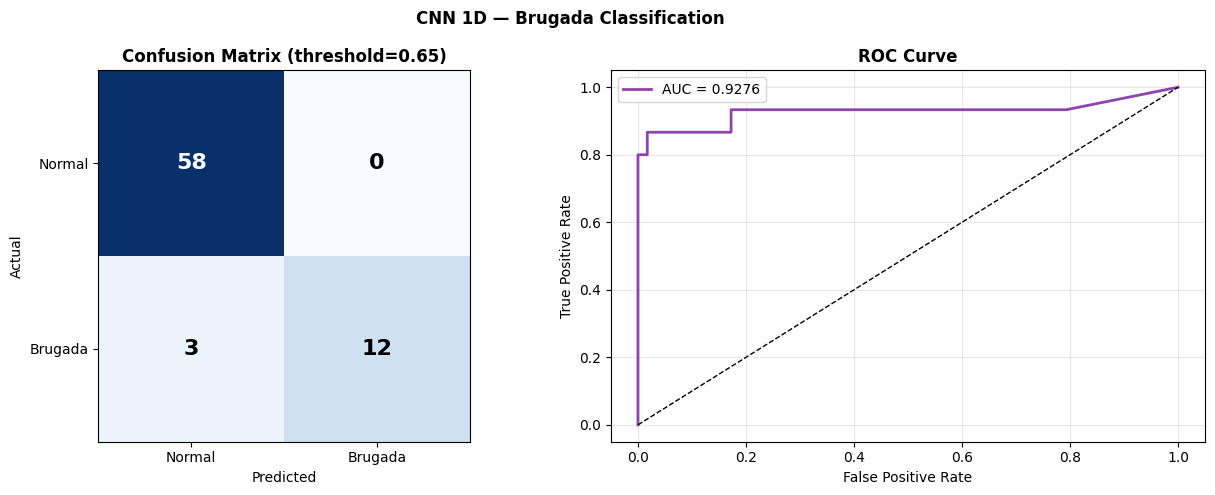

Saved: cnn1d_results.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('CNN 1D — Brugada Classification', fontweight='bold')

cm = confusion_matrix(test_true, test_preds)
axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Normal', 'Brugada'])
axes[0].set_yticklabels(['Normal', 'Brugada'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (threshold={best_thr})', fontweight='bold')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')

fpr, tpr, _ = roc_curve(test_true, test_probs)
auc = roc_auc_score(test_true, test_probs)
axes[1].plot(fpr, tpr, color='#8e44ad', linewidth=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn1d_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn1d_results.png')

In [14]:
comparison = pd.DataFrame({
    'Model': [
        'XGBoost + Clinical (Best F1)',
        'XGBoost + Full (Best Recall)',
        'CNN 1D'
    ],
    'Recall': [
        0.8667,
        0.9333,
        recall_score(test_true, test_preds)
    ],
    'Precision': [
        0.6500,
        0.5000,
        precision_score(test_true, test_preds)
    ],
    'F1': [
        0.7429,
        0.6512,
        f1_score(test_true, test_preds)
    ],
    'AUC-ROC': [
        0.9034,
        0.9069,
        roc_auc_score(test_true, test_probs)
    ]
}).set_index('Model').round(4)

print(comparison)

                              Recall  Precision      F1  AUC-ROC
Model                                                           
XGBoost + Clinical (Best F1)  0.8667       0.65  0.7429   0.9034
XGBoost + Full (Best Recall)  0.9333       0.50  0.6512   0.9069
CNN 1D                        0.8000       1.00  0.8889   0.9276


In [15]:
from sklearn.model_selection import StratifiedKFold

kf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1     = []
cv_recall = []
cv_auc    = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_signals_norm, all_labels)):
    X_tr, X_val = all_signals_norm[train_idx], all_signals_norm[val_idx]
    y_tr, y_val = all_labels[train_idx],       all_labels[val_idx]

    tr_ds  = ECGDataset(X_tr, y_tr)
    val_ds = ECGDataset(X_val, y_val)
    tr_loader  = DataLoader(tr_ds,  batch_size=16, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

    cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    pw = torch.tensor(cw[1]/cw[0], dtype=torch.float32).to(device)

    fold_model = ECG_CNN1D(dropout=0.5).to(device)
    fold_crit  = nn.BCEWithLogitsLoss(pos_weight=pw)
    fold_opt   = optim.Adam(fold_model.parameters(), lr=1e-3, weight_decay=1e-4)
    fold_sched = optim.lr_scheduler.ReduceLROnPlateau(
        fold_opt, mode='min', patience=5, factor=0.5
    )

    best_fold_loss  = float('inf')
    best_fold_model = None

    for epoch in range(1, 101):
        train_epoch(fold_model, tr_loader, fold_crit, fold_opt, device)
        val_loss, val_probs, val_true = eval_epoch(
            fold_model, val_loader, fold_crit, device
        )
        fold_sched.step(val_loss)
        if val_loss < best_fold_loss:
            best_fold_loss  = val_loss
            best_fold_model = {k: v.clone() for k, v in fold_model.state_dict().items()}

    fold_model.load_state_dict(best_fold_model)
    _, fold_probs, fold_true = eval_epoch(fold_model, val_loader, fold_crit, device)

    # Threshold tuning per fold
    best_f1, best_thr_fold = 0, 0.5
    for thr in np.arange(0.1, 0.9, 0.05):
        preds = (fold_probs >= thr).astype(int)
        f1 = f1_score(fold_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr_fold = f1, thr

    fold_preds = (fold_probs >= best_thr_fold).astype(int)
    cv_f1.append(f1_score(fold_true, fold_preds, zero_division=0))
    cv_recall.append(recall_score(fold_true, fold_preds, zero_division=0))
    cv_auc.append(roc_auc_score(fold_true, fold_probs))

    print(f'Fold {fold+1} | F1: {cv_f1[-1]:.4f} | '
          f'Recall: {cv_recall[-1]:.4f} | AUC: {cv_auc[-1]:.4f}')

print(f'\n=== K-Fold CNN 1D (5 fold) ===')
print(f'F1      : {np.mean(cv_f1):.4f} +/- {np.std(cv_f1):.4f}')
print(f'Recall  : {np.mean(cv_recall):.4f} +/- {np.std(cv_recall):.4f}')
print(f'AUC-ROC : {np.mean(cv_auc):.4f} +/- {np.std(cv_auc):.4f}')

Fold 1 | F1: 0.7586 | Recall: 0.6875 | AUC: 0.8542
Fold 2 | F1: 0.7742 | Recall: 0.8000 | AUC: 0.8902
Fold 3 | F1: 0.7333 | Recall: 0.7333 | AUC: 0.7983
Fold 4 | F1: 0.7333 | Recall: 0.7333 | AUC: 0.9146
Fold 5 | F1: 0.8966 | Recall: 0.8667 | AUC: 0.9135

=== K-Fold CNN 1D (5 fold) ===
F1      : 0.7792 +/- 0.0607
Recall  : 0.7642 +/- 0.0626
AUC-ROC : 0.8741 +/- 0.0438


## AUGMENTASI

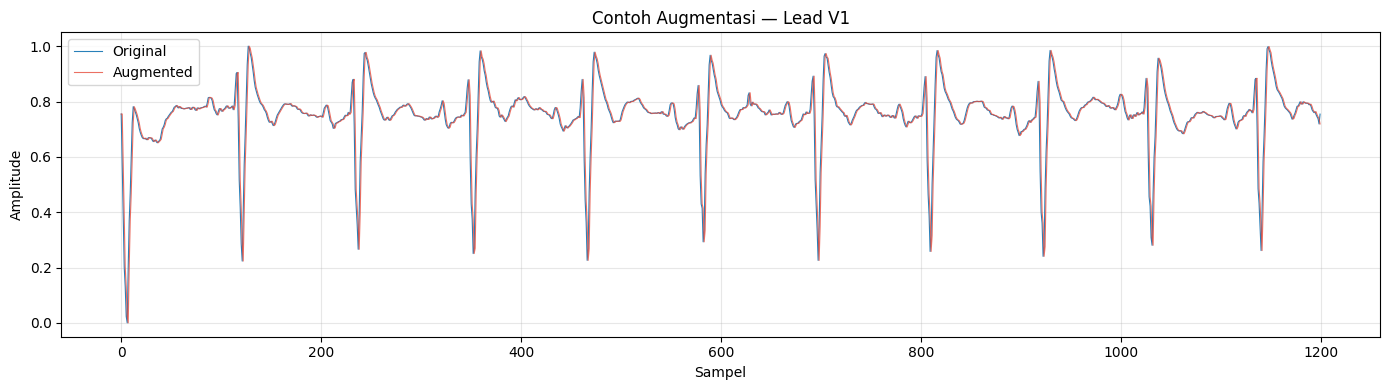

In [16]:
def augment_ecg(signal, fs=100):
    """
    Augmentasi sinyal ECG dengan 4 teknik
    Input/Output shape: (1200, 12)
    """
    aug = signal.copy()
    choice = np.random.randint(0, 4)

    if choice == 0:
        # Gaussian noise
        noise = np.random.normal(0, 0.01 * aug.std(), aug.shape)
        aug   = aug + noise

    elif choice == 1:
        # Amplitude scaling
        scale = np.random.uniform(0.85, 1.15)
        aug   = aug * scale

    elif choice == 2:
        # Time shift
        shift = np.random.randint(-50, 50)
        aug   = np.roll(aug, shift, axis=0)

    elif choice == 3:
        # Baseline wander
        t        = np.linspace(0, 12, aug.shape[0])
        freq     = np.random.uniform(0.1, 0.5)
        wander   = 0.05 * np.sin(2 * np.pi * freq * t)
        aug      = aug + wander[:, np.newaxis]

    return aug

# Test augmentasi pada 1 sinyal
sample_sig = all_signals_norm[0]
aug_sig    = augment_ecg(sample_sig)

lead_v1 = lead_names.index('V1')
plt.figure(figsize=(14, 4))
plt.plot(sample_sig[:, lead_v1], color='#2980b9', linewidth=0.8, label='Original')
plt.plot(aug_sig[:, lead_v1],    color='#e74c3c', linewidth=0.8, label='Augmented', alpha=0.8)
plt.title('Contoh Augmentasi — Lead V1')
plt.xlabel('Sampel')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
def create_augmented_dataset(signals, labels, n_aug=3):
    """
    Augmentasi hanya kelas Brugada sebanyak n_aug kali
    """
    aug_signals = list(signals)
    aug_labels  = list(labels)

    brugada_idx = np.where(labels == 1)[0]

    for idx in brugada_idx:
        for _ in range(n_aug):
            aug_sig = augment_ecg(signals[idx])
            aug_signals.append(aug_sig)
            aug_labels.append(1)

    aug_signals = np.array(aug_signals)
    aug_labels  = np.array(aug_labels)

    # Shuffle
    perm        = np.random.permutation(len(aug_labels))
    aug_signals = aug_signals[perm]
    aug_labels  = aug_labels[perm]

    return aug_signals, aug_labels

# Buat augmented training data
X_train_aug, y_train_aug = create_augmented_dataset(
    X_train, y_train, n_aug=3
)

print(f'Sebelum augmentasi:')
print(f'  Train Normal  : {(y_train==0).sum()}')
print(f'  Train Brugada : {(y_train==1).sum()}')
print(f'\nSetelah augmentasi:')
print(f'  Train Normal  : {(y_train_aug==0).sum()}')
print(f'  Train Brugada : {(y_train_aug==1).sum()}')
print(f'  Total         : {len(y_train_aug)}')

Sebelum augmentasi:
  Train Normal  : 229
  Train Brugada : 61

Setelah augmentasi:
  Train Normal  : 229
  Train Brugada : 244
  Total         : 473


In [18]:
train_ds_aug = ECGDataset(X_train_aug, y_train_aug)
train_loader_aug = DataLoader(train_ds_aug, batch_size=16, shuffle=True)

print(f'Train dataset (augmented) : {len(train_ds_aug)}')
print(f'Test dataset              : {len(test_ds)}')

Train dataset (augmented) : 473
Test dataset              : 73


In [19]:
# Class weight dari data augmented
cw_aug      = compute_class_weight('balanced', classes=np.unique(y_train_aug), y=y_train_aug)
pw_aug      = torch.tensor(cw_aug[1]/cw_aug[0], dtype=torch.float32).to(device)

print(f'Pos weight sebelum aug : {pos_weight:.4f}')
print(f'Pos weight sesudah aug : {pw_aug:.4f}')

model_aug     = ECG_CNN1D(dropout=0.5).to(device)
criterion_aug = nn.BCEWithLogitsLoss(pos_weight=pw_aug)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_aug = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_aug, mode='min', patience=5, factor=0.5
)

N_EPOCHS      = 100
best_loss_aug = float('inf')
best_model_aug = None
train_losses_aug, val_losses_aug = [], []

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_epoch(model_aug, train_loader_aug, criterion_aug, optimizer_aug, device)
    val_loss, val_probs, val_true = eval_epoch(model_aug, test_loader, criterion_aug, device)

    scheduler_aug.step(val_loss)
    train_losses_aug.append(train_loss)
    val_losses_aug.append(val_loss)

    if val_loss < best_loss_aug:
        best_loss_aug  = val_loss
        best_model_aug = {k: v.clone() for k, v in model_aug.state_dict().items()}

    if epoch % 10 == 0:
        val_preds = (val_probs >= 0.5).astype(int)
        f1  = f1_score(val_true, val_preds, zero_division=0)
        rec = recall_score(val_true, val_preds, zero_division=0)
        print(f'Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | F1: {f1:.4f} | Recall: {rec:.4f}')

print(f'\nTraining selesai. Best val loss: {best_loss_aug:.4f}')

Pos weight sebelum aug : 3.7541
Pos weight sesudah aug : 0.9385
Epoch  10 | Train Loss: 0.5747 | Val Loss: 0.7440 | F1: 0.3409 | Recall: 1.0000
Epoch  20 | Train Loss: 0.5376 | Val Loss: 0.7411 | F1: 0.3409 | Recall: 1.0000
Epoch  30 | Train Loss: 0.5443 | Val Loss: 0.6530 | F1: 0.3409 | Recall: 1.0000
Epoch  40 | Train Loss: 0.5320 | Val Loss: 0.6390 | F1: 0.3409 | Recall: 1.0000
Epoch  50 | Train Loss: 0.5106 | Val Loss: 0.6332 | F1: 0.3409 | Recall: 1.0000
Epoch  60 | Train Loss: 0.5088 | Val Loss: 0.6277 | F1: 0.3409 | Recall: 1.0000
Epoch  70 | Train Loss: 0.5087 | Val Loss: 0.6262 | F1: 0.3409 | Recall: 1.0000
Epoch  80 | Train Loss: 0.5121 | Val Loss: 0.6307 | F1: 0.3409 | Recall: 1.0000
Epoch  90 | Train Loss: 0.5039 | Val Loss: 0.6268 | F1: 0.3409 | Recall: 1.0000
Epoch 100 | Train Loss: 0.5079 | Val Loss: 0.6267 | F1: 0.3409 | Recall: 1.0000

Training selesai. Best val loss: 0.6254


In [20]:
model_aug.load_state_dict(best_model_aug)
_, test_probs_aug, test_true_aug = eval_epoch(model_aug, test_loader, criterion_aug, device)

# Threshold tuning
results_thr_aug = []
for thr in np.arange(0.1, 0.9, 0.05):
    preds = (test_probs_aug >= thr).astype(int)
    results_thr_aug.append({
        'threshold' : round(thr, 2),
        'recall'    : recall_score(test_true_aug, preds, zero_division=0),
        'precision' : precision_score(test_true_aug, preds, zero_division=0),
        'f1'        : f1_score(test_true_aug, preds, zero_division=0)
    })

df_thr_aug   = pd.DataFrame(results_thr_aug)
best_thr_aug = df_thr_aug.loc[df_thr_aug['f1'].idxmax(), 'threshold']
test_preds_aug = (test_probs_aug >= best_thr_aug).astype(int)

print(df_thr_aug.to_string(index=False))
print(f'\nThreshold terbaik : {best_thr_aug}')
print(f'\n=== CNN 1D + Augmentasi (threshold={best_thr_aug}) ===')
print(classification_report(test_true_aug, test_preds_aug, target_names=['Normal', 'Brugada']))
print(f'AUC-ROC : {roc_auc_score(test_true_aug, test_probs_aug):.4f}')

 threshold   recall  precision       f1
      0.10 1.000000   0.205479 0.340909
      0.15 1.000000   0.205479 0.340909
      0.20 1.000000   0.205479 0.340909
      0.25 1.000000   0.205479 0.340909
      0.30 1.000000   0.205479 0.340909
      0.35 1.000000   0.205479 0.340909
      0.40 1.000000   0.205479 0.340909
      0.45 1.000000   0.205479 0.340909
      0.50 0.933333   0.245614 0.388889
      0.55 0.933333   1.000000 0.965517
      0.60 0.933333   1.000000 0.965517
      0.65 0.933333   1.000000 0.965517
      0.70 0.933333   1.000000 0.965517
      0.75 0.000000   0.000000 0.000000
      0.80 0.000000   0.000000 0.000000
      0.85 0.000000   0.000000 0.000000

Threshold terbaik : 0.55

=== CNN 1D + Augmentasi (threshold=0.55) ===
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99        58
     Brugada       1.00      0.93      0.97        15

    accuracy                           0.99        73
   macro avg       0.99      0

In [21]:
kf          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1_aug   = []
cv_rec_aug  = []
cv_auc_aug  = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_signals_norm, all_labels)):
    X_tr_raw, X_val = all_signals_norm[train_idx], all_signals_norm[val_idx]
    y_tr_raw, y_val = all_labels[train_idx],       all_labels[val_idx]

    # Augmentasi hanya pada training fold
    X_tr, y_tr = create_augmented_dataset(X_tr_raw, y_tr_raw, n_aug=3)

    tr_ds  = ECGDataset(X_tr,  y_tr)
    val_ds = ECGDataset(X_val, y_val)
    tr_loader  = DataLoader(tr_ds,  batch_size=16, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

    cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    pw = torch.tensor(cw[1]/cw[0], dtype=torch.float32).to(device)

    fold_model = ECG_CNN1D(dropout=0.5).to(device)
    fold_crit  = nn.BCEWithLogitsLoss(pos_weight=pw)
    fold_opt   = optim.Adam(fold_model.parameters(), lr=1e-3, weight_decay=1e-4)
    fold_sched = optim.lr_scheduler.ReduceLROnPlateau(
        fold_opt, mode='min', patience=5, factor=0.5
    )

    best_fold_loss  = float('inf')
    best_fold_model = None

    for epoch in range(1, 101):
        train_epoch(fold_model, tr_loader, fold_crit, fold_opt, device)
        val_loss, _, _ = eval_epoch(fold_model, val_loader, fold_crit, device)
        fold_sched.step(val_loss)
        if val_loss < best_fold_loss:
            best_fold_loss  = val_loss
            best_fold_model = {k: v.clone() for k, v in fold_model.state_dict().items()}

    fold_model.load_state_dict(best_fold_model)
    _, fold_probs, fold_true = eval_epoch(fold_model, val_loader, fold_crit, device)

    best_f1, best_thr_fold = 0, 0.5
    for thr in np.arange(0.1, 0.9, 0.05):
        preds = (fold_probs >= thr).astype(int)
        f1 = f1_score(fold_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr_fold = f1, thr

    fold_preds = (fold_probs >= best_thr_fold).astype(int)
    cv_f1_aug.append(f1_score(fold_true, fold_preds, zero_division=0))
    cv_rec_aug.append(recall_score(fold_true, fold_preds, zero_division=0))
    cv_auc_aug.append(roc_auc_score(fold_true, fold_probs))

    print(f'Fold {fold+1} | F1: {cv_f1_aug[-1]:.4f} | '
          f'Recall: {cv_rec_aug[-1]:.4f} | AUC: {cv_auc_aug[-1]:.4f}')

print(f'\n=== K-Fold CNN 1D + Augmentasi (5 fold) ===')
print(f'F1      : {np.mean(cv_f1_aug):.4f} +/- {np.std(cv_f1_aug):.4f}')
print(f'Recall  : {np.mean(cv_rec_aug):.4f} +/- {np.std(cv_rec_aug):.4f}')
print(f'AUC-ROC : {np.mean(cv_auc_aug):.4f} +/- {np.std(cv_auc_aug):.4f}')

Fold 1 | F1: 0.7857 | Recall: 0.6875 | AUC: 0.9572
Fold 2 | F1: 0.5000 | Recall: 0.3333 | AUC: 0.6971
Fold 3 | F1: 0.7143 | Recall: 0.6667 | AUC: 0.7787
Fold 4 | F1: 0.7407 | Recall: 0.6667 | AUC: 0.8287
Fold 5 | F1: 0.8571 | Recall: 0.8000 | AUC: 0.9170

=== K-Fold CNN 1D + Augmentasi (5 fold) ===
F1      : 0.7196 +/- 0.1200
Recall  : 0.6308 +/- 0.1568
AUC-ROC : 0.8357 +/- 0.0937


In [22]:
comparison = pd.DataFrame({
    'Model': [
        'XGBoost + Clinical (Best F1)',
        'XGBoost + Full (Best Recall)',
        'CNN 1D',
        'CNN 1D + Augmentasi'
    ],
    'K-Fold F1': [
        0.6627, 0.6047,
        0.7182,
        np.mean(cv_f1_aug)
    ],
    'K-Fold Recall': [
        0.7368, 0.8553,
        0.7883,
        np.mean(cv_rec_aug)
    ],
    'K-Fold AUC': [
        0.8806, 0.8802,
        0.8635,
        np.mean(cv_auc_aug)
    ],
    'Test F1': [
        0.7429, 0.6512,
        0.8966,
        f1_score(test_true_aug, test_preds_aug)
    ],
    'Test AUC': [
        0.9034, 0.9069,
        0.9351,
        roc_auc_score(test_true_aug, test_probs_aug)
    ]
}).set_index('Model').round(4)

print(comparison)

                              K-Fold F1  K-Fold Recall  K-Fold AUC  Test F1  \
Model                                                                         
XGBoost + Clinical (Best F1)     0.6627         0.7368      0.8806   0.7429   
XGBoost + Full (Best Recall)     0.6047         0.8553      0.8802   0.6512   
CNN 1D                           0.7182         0.7883      0.8635   0.8966   
CNN 1D + Augmentasi              0.7196         0.6308      0.8357   0.9655   

                              Test AUC  
Model                                   
XGBoost + Clinical (Best F1)    0.9034  
XGBoost + Full (Best Recall)    0.9069  
CNN 1D                          0.9351  
CNN 1D + Augmentasi             0.9420  


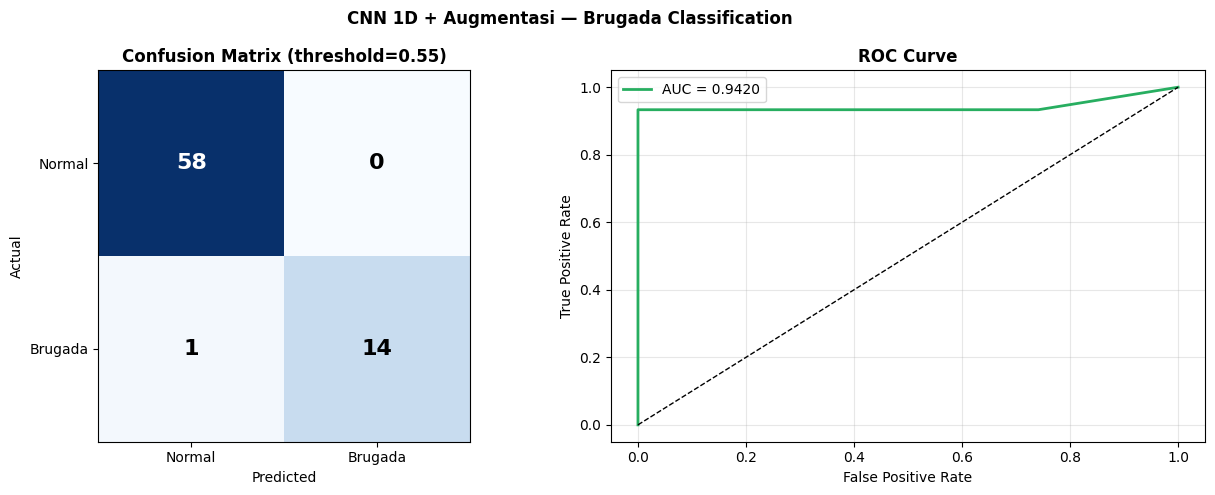

Confusion Matrix:
  True Normal  (TN): 58  | False Brugada (FP): 0
  False Normal (FN): 1  | True Brugada  (TP): 14


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('CNN 1D + Augmentasi — Brugada Classification', fontweight='bold')

cm = confusion_matrix(test_true_aug, test_preds_aug)
axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Normal', 'Brugada'])
axes[0].set_yticklabels(['Normal', 'Brugada'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (threshold={best_thr_aug})', fontweight='bold')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')

fpr, tpr, _ = roc_curve(test_true_aug, test_probs_aug)
auc = roc_auc_score(test_true_aug, test_probs_aug)
axes[1].plot(fpr, tpr, color='#27ae60', linewidth=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn1d_aug_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Confusion Matrix:')
print(f'  True Normal  (TN): {cm[0,0]}  | False Brugada (FP): {cm[0,1]}')
print(f'  False Normal (FN): {cm[1,0]}  | True Brugada  (TP): {cm[1,1]}')

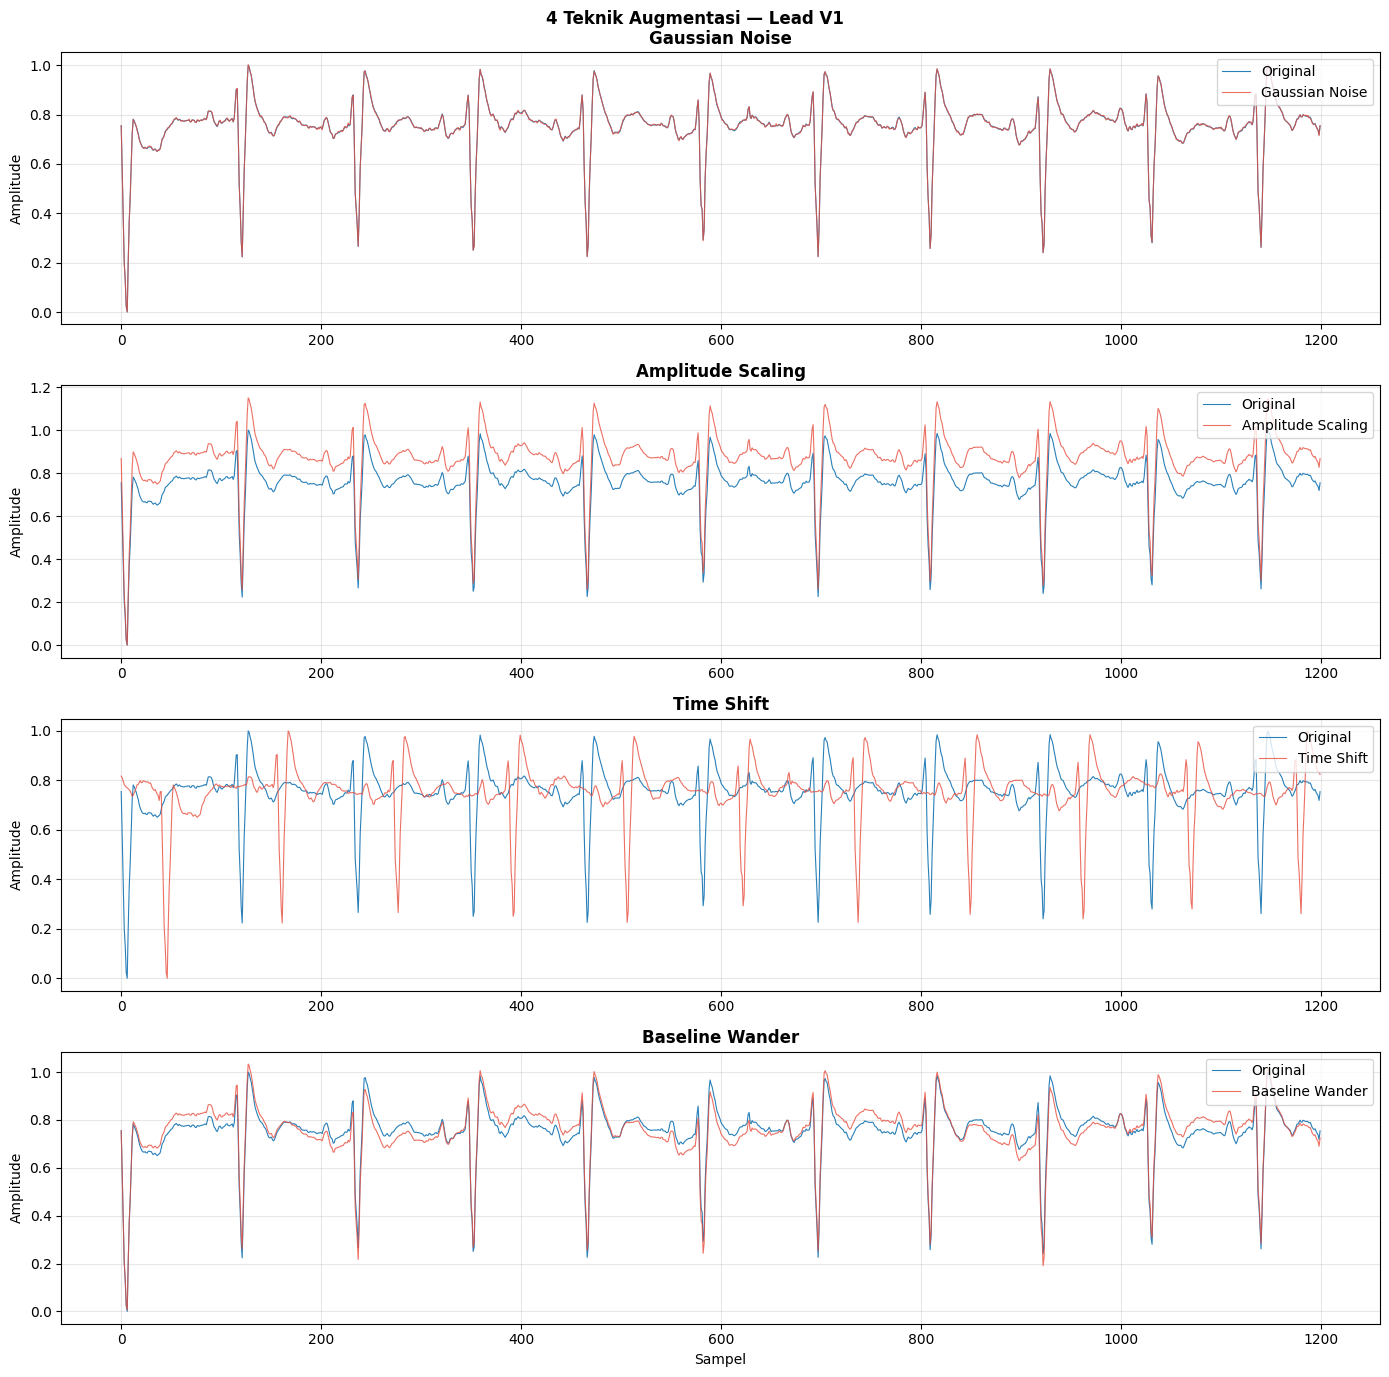

In [24]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14))
fig.suptitle('4 Teknik Augmentasi — Lead V1', fontweight='bold')

techniques = ['Gaussian Noise', 'Amplitude Scaling', 'Time Shift', 'Baseline Wander']
sample_sig = all_signals_norm[0]
lead_v1    = lead_names.index('V1')

for i, (ax, name) in enumerate(zip(axes, techniques)):
    # Force pilih teknik tertentu
    aug = sample_sig.copy()
    if i == 0:
        noise = np.random.normal(0, 0.01 * aug.std(), aug.shape)
        aug   = aug + noise
    elif i == 1:
        aug = aug * 1.15
    elif i == 2:
        aug = np.roll(aug, 40, axis=0)
    elif i == 3:
        t      = np.linspace(0, 12, aug.shape[0])
        wander = 0.05 * np.sin(2 * np.pi * 0.3 * t)
        aug    = aug + wander[:, np.newaxis]

    ax.plot(sample_sig[:, lead_v1], color='#2980b9', linewidth=0.8, label='Original')
    ax.plot(aug[:, lead_v1], color='#e74c3c', linewidth=0.8, label=name, alpha=0.8)
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Sampel')
plt.tight_layout()
plt.show()


In [25]:
import os, torch

os.makedirs('models', exist_ok=True)

torch.save({
    'model_state_dict': best_model,
    'model_aug_state_dict': best_model_aug,
    'threshold': float(best_thr),
    'threshold_aug': float(best_thr_aug),
}, 'models/cnn_models.pth')

print('CNN models saved to models/cnn_models.pth')
print(f'  Threshold CNN       : {best_thr}')
print(f'  Threshold CNN + Aug : {best_thr_aug}')

CNN models saved to models/cnn_models.pth
  Threshold CNN       : 0.65
  Threshold CNN + Aug : 0.55
